In [1]:
install.packages("forecast")
install.packages("ggplot2")
install.packages("dplyr")
install.packages("readr")

library(forecast)
library(ggplot2)
library(dplyr)
library(readr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘quantmod’, ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘tseries’, ‘urca’, ‘zoo’, ‘RcppArmadillo’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
# Change filenames if needed
jembe_raw    <- read_csv("jembe.csv")
ngelehun_raw <- read_csv("Ngelehun.csv")

# Columns to ignore when summing
ignore_cols <- c("periodid", "periodcode", "periodname")

# Identify numeric referral columns
referral_cols <- jembe_raw %>%
  select(-any_of(ignore_cols)) %>%
  select(where(is.numeric)) %>%
  names()

# Add facility label + total_referrals
jembe <- jembe_raw %>%
  mutate(
    facility = "Jembe CHC",
    total_referrals = rowSums(across(all_of(referral_cols)), na.rm = TRUE)
  )

ngelehun <- ngelehun_raw %>%
  mutate(
    facility = "Ngelehun CHC",
    total_referrals = rowSums(across(all_of(referral_cols)), na.rm = TRUE)
  )

# Combine and add Date from periodcode (YYYYMM)
referrals_df <- bind_rows(jembe, ngelehun) %>%
  mutate(
    date = as.Date(paste0(periodcode, "01"), format = "%Y%m%d")
  ) %>%
  arrange(facility, date)

head(referrals_df)


Rows: 24 Columns: 34
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): periodname
dbl (16): periodid, periodcode, All other referrals, Anaemia referrals, Burn...
lgl (17): perioddescription, Acute Flaccid Paralysis (AFP) referrals, Diarrh...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 24 Columns: 34
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): periodname
dbl (30): periodid, periodcode, Acute Flaccid Paralysis (AFP) referrals, All...
lgl  (3): perioddescription, PLHIVs referred for TB screening, PLHIVs referr...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


periodid,periodname,periodcode,perioddescription,Acute Flaccid Paralysis (AFP) referrals,All other referrals,Anaemia referrals,Burns referrals,Clinical Malnutrition referrals,Diarrhoea with blood (Dysentery) referrals,⋯,Tetanus (not incl. 0-28 days) referrals,Tuberculosis referrals,Typhoid fever referrals,Worm infestation referrals,Wounds/Trauma referrals,Yaws referrals,Yellow fever referrals,facility,total_referrals,date
<dbl>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<date>
202401,January 2024,202401,NA,NA,NA,4,2,4,NA,⋯,NA,1,NA,NA,2,NA,NA,Jembe CHC,26,2024-01-01
202402,February 2024,202402,NA,NA,9,5,NA,3,NA,⋯,NA,2,NA,10,NA,NA,NA,Jembe CHC,48,2024-02-01
202403,March 2024,202403,NA,NA,10,20,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,Jembe CHC,64,2024-03-01
202404,April 2024,202404,NA,NA,5,4,NA,1,NA,⋯,NA,NA,NA,NA,3,NA,NA,Jembe CHC,43,2024-04-01
202405,May 2024,202405,NA,NA,7,13,1,4,NA,⋯,NA,NA,NA,NA,4,NA,NA,Jembe CHC,42,2024-05-01
202406,June 2024,202406,NA,NA,5,26,NA,5,NA,⋯,NA,NA,NA,NA,NA,NA,NA,Jembe CHC,71,2024-06-01


In [3]:
ts_df <- referrals_df %>%
  select(facility, date, total_referrals) %>%
  arrange(facility, date)

# Jembe CHC
jembe_vec <- ts_df %>%
  filter(facility == "Jembe CHC") %>%
  pull(total_referrals)

jembe_ts <- ts(jembe_vec, frequency = 12)

# Ngelehun CHC
ng_vec <- ts_df %>%
  filter(facility == "Ngelehun CHC") %>%
  pull(total_referrals)

ng_ts <- ts(ng_vec, frequency = 12)

jembe_ts
ng_ts


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
1,26,48,64,43,42,71,82,55,79,46,49,42
2,26,48,43,64,42,71,82,55,79,49,46,42


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
1,43,0,3,0,2,2,2,1,0,0,0,0
2,43,6,17,7,13,14,13,7,14,51,0,0


In [4]:
ts_metrics <- function(actual, pred) {
  actual <- as.numeric(actual)
  pred   <- as.numeric(pred)

  n <- min(length(actual), length(pred))
  actual <- actual[1:n]
  pred   <- pred[1:n]

  ok <- !(is.na(actual) | is.na(pred))
  actual <- actual[ok]
  pred   <- pred[ok]

  if (length(actual) == 0) {
    return(data.frame(MAE = NA, RMSE = NA, MAPE = NA, R2 = NA))
  }

  mae  <- mean(abs(actual - pred))
  rmse <- sqrt(mean((actual - pred)^2))

  denom <- ifelse(actual == 0, NA, actual)
  mape <- mean(abs(actual - pred) / denom * 100, na.rm = TRUE)

  if (var(actual) == 0) {
    r2 <- NA
  } else {
    r2 <- 1 - sum((actual - pred)^2) / sum((actual - mean(actual))^2)
  }

  data.frame(MAE = mae, RMSE = rmse, MAPE = mape, R2 = r2)
}


In [5]:
fit_and_forecast <- function(series, h_test = 6, h_future = 12) {
  n <- length(series)

  # Train/Test split
  train <- ts(series[1:(n - h_test)], frequency = 12)
  test  <- ts(series[(n - h_test + 1):n], frequency = 12)

  # Fit models on TRAIN
  ets_fit   <- ets(train)
  arima_fit <- auto.arima(train, seasonal = TRUE)

  # Forecast on TEST window
  ets_fc_test   <- forecast(ets_fit,   h = h_test)
  arima_fc_test <- forecast(arima_fit, h = h_test)

  # Validation metrics
  ets_metrics   <- ts_metrics(test, ets_fc_test$mean)
  arima_metrics <- ts_metrics(test, arima_fc_test$mean)

  ets_metrics$model   <- "ETS"
  arima_metrics$model <- "ARIMA"

  val_results <- rbind(ets_metrics, arima_metrics)

  # Refit on FULL data for future 12 months
  ets_full   <- ets(series)
  arima_full <- auto.arima(series, seasonal = TRUE)

  ets_future   <- forecast(ets_full,   h = h_future)
  arima_future <- forecast(arima_full, h = h_future)

  list(
    val_results    = val_results,
    test           = test,
    ets_fc_test    = ets_fc_test,
    arima_fc_test  = arima_fc_test,
    ets_full       = ets_full,
    arima_full     = arima_full,
    ets_future     = ets_future,
    arima_future   = arima_future
  )
}


In [6]:
h_test   <- 6      # last 6 months as validation window
h_future <- 12     # forecast next 12 months

# Jembe
jembe_models <- fit_and_forecast(jembe_ts, h_test = h_test, h_future = h_future)

# Ngelehun
ngelehun_models <- fit_and_forecast(ng_ts, h_test = h_test, h_future = h_future)

# Print validation tables (like in your screenshot)
cat("=== Validation – Jembe CHC ===\n")
print(jembe_models$val_results)

cat("\n=== Validation – Ngelehun CHC ===\n")
print(ngelehun_models$val_results)


=== Validation – Jembe CHC ===
       MAE     RMSE     MAPE         R2 model
1 13.16667 17.12871 19.97315 -0.1713576   ETS
2 13.16667 17.13031 19.97155 -0.1715771 ARIMA

=== Validation – Ngelehun CHC ===
       MAE     RMSE     MAPE         R2 model
1 11.96367 18.94529 48.64533 -0.1892554   ETS
2 11.83333 18.27339 44.66575 -0.1063967 ARIMA


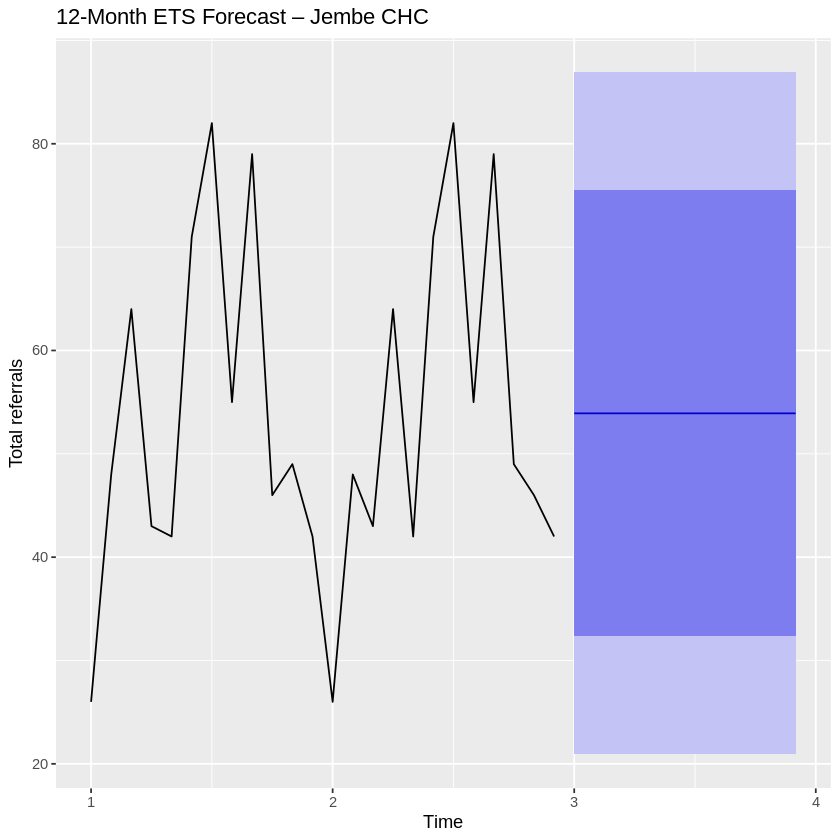

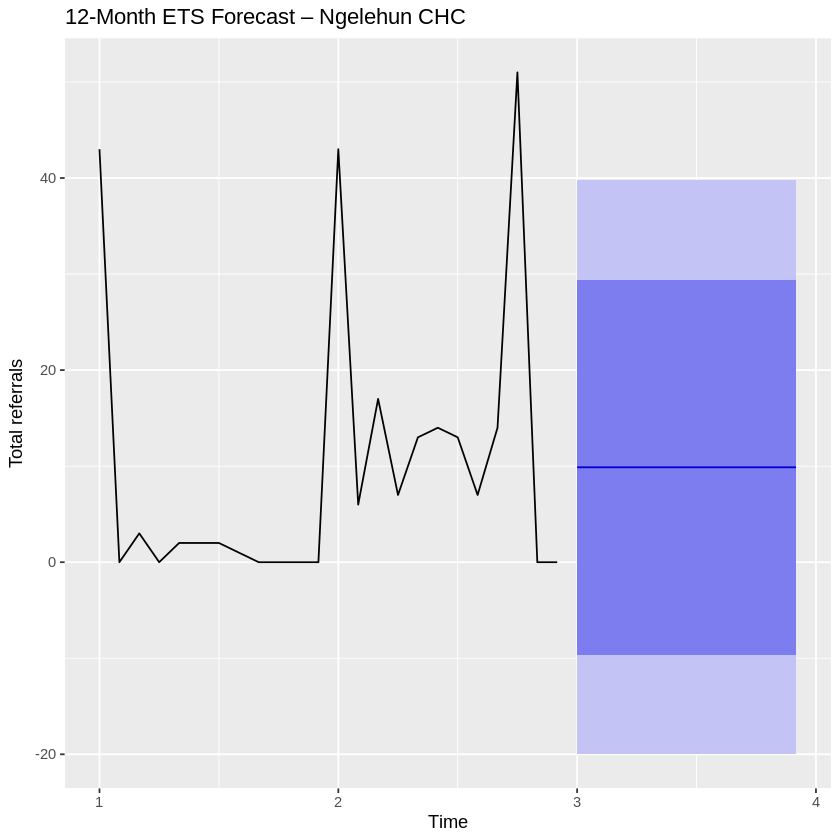

In [7]:
# Jembe – ETS future forecast
autoplot(jembe_models$ets_future) +
  ggtitle("12-Month ETS Forecast – Jembe CHC") +
  ylab("Total referrals") + xlab("Time")

# Ngelehun – ETS future forecast
autoplot(ngelehun_models$ets_future) +
  ggtitle("12-Month ETS Forecast – Ngelehun CHC") +
  ylab("Total referrals") + xlab("Time")


In [8]:
# Dates for the last 6 months (Jembe)
dates_jembe_test <- ts_df %>%
  filter(facility == "Jembe CHC") %>%
  pull(date) %>%
  tail(h_test)

# Dates for the last 6 months (Ngelehun)
dates_ng_test <- ts_df %>%
  filter(facility == "Ngelehun CHC") %>%
  pull(date) %>%
  tail(h_test)

# Jembe – Actual vs predicted
df_jembe_val <- data.frame(
  Date   = dates_jembe_test,
  Actual = as.numeric(jembe_models$test),
  ETS    = as.numeric(jembe_models$ets_fc_test$mean),
  ARIMA  = as.numeric(jembe_models$arima_fc_test$mean)
)

# Ngelehun – Actual vs predicted
df_ng_val <- data.frame(
  Date   = dates_ng_test,
  Actual = as.numeric(ngelehun_models$test),
  ETS    = as.numeric(ngelehun_models$ets_fc_test$mean),
  ARIMA  = as.numeric(ngelehun_models$arima_fc_test$mean)
)

head(df_jembe_val)
head(df_ng_val)


,Date,Actual,ETS,ARIMA
,<date>,<dbl>,<dbl>,<dbl>
1,2025-07-01,82,52.28197,52.27778
2,2025-08-01,55,52.28197,52.27778
3,2025-09-01,79,52.28197,52.27778
4,2025-10-01,49,52.28197,52.27778
5,2025-11-01,46,52.28197,52.27778
6,2025-12-01,42,52.28197,52.27778


,Date,Actual,ETS,ARIMA
,<date>,<dbl>,<dbl>,<dbl>
1,2025-07-01,13,6.608999,8.5
2,2025-08-01,7,6.608999,8.5
3,2025-09-01,14,6.608999,8.5
4,2025-10-01,51,6.608999,8.5
5,2025-11-01,0,6.608999,8.5
6,2025-12-01,0,6.608999,8.5


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


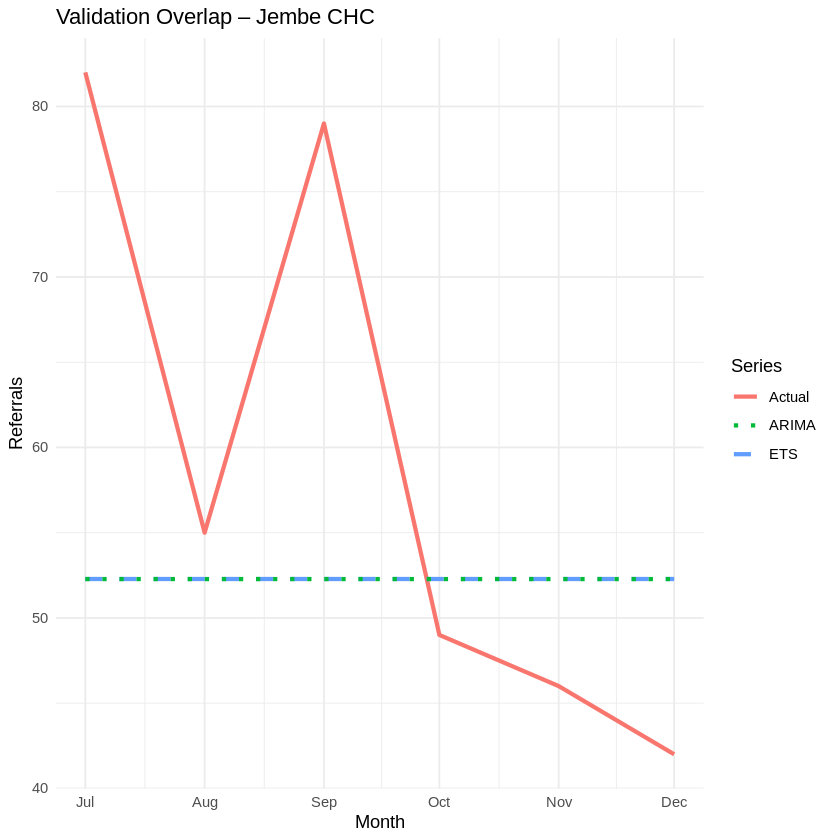

In [9]:
ggplot(df_jembe_val, aes(x = Date)) +
  geom_line(aes(y = Actual, color = "Actual"), size = 1.2) +
  geom_line(aes(y = ETS,    color = "ETS"),    size = 1.2, linetype = "dashed") +
  geom_line(aes(y = ARIMA,  color = "ARIMA"),  size = 1.2, linetype = "dotted") +
  labs(
    title = "Validation Overlap – Jembe CHC",
    x = "Month", y = "Referrals",
    color = "Series"
  ) +
  theme_minimal()


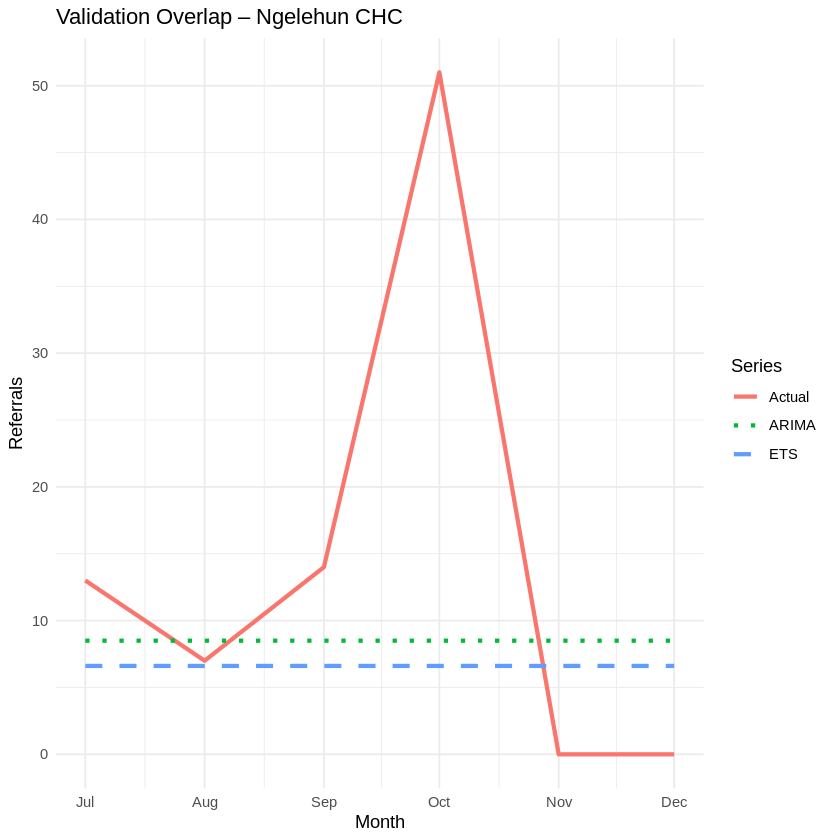

In [10]:
ggplot(df_ng_val, aes(x = Date)) +
  geom_line(aes(y = Actual, color = "Actual"), size = 1.2) +
  geom_line(aes(y = ETS,    color = "ETS"),    size = 1.2, linetype = "dashed") +
  geom_line(aes(y = ARIMA,  color = "ARIMA"),  size = 1.2, linetype = "dotted") +
  labs(
    title = "Validation Overlap – Ngelehun CHC",
    x = "Month", y = "Referrals",
    color = "Series"
  ) +
  theme_minimal()


In [14]:
# Extract future forecasts
jembe_future <- jembe_models$ets_future
ng_future    <- ngelehun_models$ets_future

# Convert time indexes directly to year-month strings
months <- format(seq.Date(
  from = as.Date(tail(ts_df$date, 1)) + 30,   # approximate next month
  by   = "month",
  length.out = 12
), "%b %Y")

combined_table <- data.frame(
  Month = months,

  Jembe_Forecast   = round(as.numeric(jembe_future$mean), 1),
  Jembe_Lower_80   = round(as.numeric(jembe_future$lower[, "80%"]), 1),
  Jembe_Upper_80   = round(as.numeric(jembe_future$upper[, "80%"]), 1),
  Jembe_Lower_95   = round(as.numeric(jembe_future$lower[, "95%"]), 1),
  Jembe_Upper_95   = round(as.numeric(jembe_future$upper[, "95%"]), 1),

  Ngelehun_Forecast = round(as.numeric(ng_future$mean), 1),
  Ngelehun_Lower_80 = round(as.numeric(ng_future$lower[, "80%"]), 1),
  Ngelehun_Upper_80 = round(as.numeric(ng_future$upper[, "80%"]), 1),
  Ngelehun_Lower_95 = round(as.numeric(ng_future$lower[, "95%"]), 1),
  Ngelehun_Upper_95 = round(as.numeric(ng_future$upper[, "95%"]), 1)
)

combined_table


Month,Jembe_Forecast,Jembe_Lower_80,Jembe_Upper_80,Jembe_Lower_95,Jembe_Upper_95,Ngelehun_Forecast,Ngelehun_Lower_80,Ngelehun_Upper_80,Ngelehun_Lower_95,Ngelehun_Upper_95
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Dec 2025,53.9,32.3,75.5,20.9,86.9,9.9,-9.7,29.4,-20,39.8
Jan 2026,53.9,32.3,75.5,20.9,86.9,9.9,-9.7,29.4,-20,39.8
Mar 2026,53.9,32.3,75.5,20.9,86.9,9.9,-9.7,29.4,-20,39.8
Mar 2026,53.9,32.3,75.5,20.9,86.9,9.9,-9.7,29.4,-20,39.8
May 2026,53.9,32.3,75.5,20.9,86.9,9.9,-9.7,29.4,-20,39.8
May 2026,53.9,32.3,75.5,20.9,86.9,9.9,-9.7,29.4,-20,39.8
Jul 2026,53.9,32.3,75.5,20.9,86.9,9.9,-9.7,29.4,-20,39.8
Jul 2026,53.9,32.3,75.5,20.9,86.9,9.9,-9.7,29.4,-20,39.8
Aug 2026,53.9,32.3,75.5,20.9,86.9,9.9,-9.7,29.4,-20,39.8
